# Scarlet-like residual photometry head

This notebook tests the morphology-aware photometry path. The PSF-only notebook is still useful as a compact-source baseline, but galaxies and blends should be modeled as positive morphologies convolved with the PSF, then fitted by reducing the pixel residual of the whole local scene.

The flow here is:

1. Build a VIS master catalog, preferring CenterNet when available.
2. Initialize one non-negative morphology template per source from VIS.
3. Render PSFField templates for every Euclid band at those positions.
4. Optimize local blend scenes with `fit_scarlet_like_tile`.
5. Compare residuals against the PSF-only matched-filter baseline.


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.origin'] = 'lower'


def find_repo_root(start: Path = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    return start

ROOT = find_repo_root()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'models'))

from models.photometry import (
    PSFFieldPhotometryPipeline,
    build_neighbor_groups,
    fit_scarlet_like_tile,
    make_positive_morphology_templates,
)
from astrometry2.source_matching import detect_sources, safe_header_from_card_string
from astrometry2.dataset import _to_float32, detect_sources_multiband
from load_foundation import load_foundation
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'ROOT   = {ROOT}')
print(f'DEVICE = {DEVICE}')


ROOT   = /home/shemmati/Work/Projects/JAISP
DEVICE = cuda


## Configuration

The defaults are intentionally small so the notebook can run as a diagnostic. Increase `MAX_SOURCES` and `N_STEPS` once the galleries look sensible.


In [2]:
RUBIN_DIR = ROOT / 'data' / 'rubin_tiles_all'
EUCLID_DIR = ROOT / 'data' / 'euclid_tiles_all'
PSF_CKPT = ROOT / 'models' / 'checkpoints' / 'psf_field_v3.pt'
FOUNDATION_CKPT = ROOT / 'models' / 'checkpoints' / 'jaisp_v8_fine' / 'checkpoint_best.pt'
CENTERNET_CKPT = ROOT / 'checkpoints' / 'centernet_v8_fine' / 'centernet_best.pt'
OUT_DIR = ROOT / 'io'

MAX_SOURCES = 18
MORPH_SIZE = 31
SCENE_MIN = 49
SCENE_MAX = 71
GROUP_RADIUS = 9.0
N_STEPS = 70
LR = 4e-2
SUB_GRID = 2

# CenterNet is preferred, but CPU CenterNet inference is slow for an interactive notebook.
# On a GPU machine this defaults to True. Set JAISP_FORCE_CENTERNET=1 to force it on CPU.
USE_CENTERNET = (DEVICE.type == 'cuda') or (os.environ.get('JAISP_FORCE_CENTERNET', '0') == '1')
CENTERNET_CONF = 0.30

for label, path in [
    ('Rubin dir', RUBIN_DIR),
    ('Euclid dir', EUCLID_DIR),
    ('PSF checkpoint', PSF_CKPT),
    ('Foundation', FOUNDATION_CKPT),
    ('CenterNet', CENTERNET_CKPT),
]:
    status = 'OK' if path.exists() else 'MISSING'
    shown = path.relative_to(ROOT) if path.exists() else path
    print(f'{label:15s}: {shown}  {status}')
print(f'USE_CENTERNET : {USE_CENTERNET}')


Rubin dir      : data/rubin_tiles_all  OK
Euclid dir     : data/euclid_tiles_all  OK
PSF checkpoint : models/checkpoints/psf_field_v3.pt  OK
Foundation     : models/checkpoints/jaisp_v8_fine/checkpoint_best.pt  OK
CenterNet      : checkpoints/centernet_v8_fine/centernet_best.pt  OK
USE_CENTERNET : True


In [3]:
def load_rubin_tile(path: Path):
    data = np.load(path, allow_pickle=True)
    img = np.nan_to_num(data['img'].astype('float32'), nan=0.0)
    var = data['var'].astype('float32') if 'var' in data else np.ones_like(img, dtype='float32')
    rms = np.sqrt(np.clip(var, 1e-8, None)).astype('float32')
    return {
        'path': path,
        'tile_id': str(data['tile_id']) if 'tile_id' in data else path.stem,
        'img': img,
        'var': var,
        'rms': rms,
        'wcs': WCS(data['wcs_hdr'].item()),
    }


def load_euclid_tile(path: Path):
    data = np.load(path, allow_pickle=True)
    band_keys = ['VIS', 'Y', 'J', 'H']
    imgs, rms, wcs = [], [], []
    for band in band_keys:
        img = np.nan_to_num(_to_float32(data[f'img_{band}']), nan=0.0)
        var = _to_float32(data[f'var_{band}']) if f'var_{band}' in data else np.ones_like(img, dtype='float32')
        imgs.append(img)
        rms.append(np.sqrt(np.clip(var, 1e-8, None)).astype('float32'))
        wcs.append(WCS(safe_header_from_card_string(data[f'wcs_{band}'].item())))
    return {
        'path': path,
        'tile_id': path.stem.replace('_euclid', ''),
        'img': np.stack(imgs).astype('float32'),
        'rms': np.stack(rms).astype('float32'),
        'wcs': wcs,
        'band_names': ['euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H'],
    }


def project_xy(source_xy, source_wcs, target_wcs):
    source_xy = np.asarray(source_xy, dtype=np.float32)
    if source_xy.size == 0:
        return np.zeros((0, 2), dtype=np.float32)
    ra, dec = source_wcs.wcs_pix2world(source_xy[:, 0], source_xy[:, 1], 0)
    tx, ty = target_wcs.wcs_world2pix(ra, dec, 0)
    return np.stack([tx, ty], axis=1).astype('float32')


def in_margin(xy, shape, margin):
    H, W = shape
    xy = np.asarray(xy, dtype=np.float32)
    return (
        np.isfinite(xy[:, 0]) & np.isfinite(xy[:, 1])
        & (xy[:, 0] >= margin) & (xy[:, 0] < W - margin)
        & (xy[:, 1] >= margin) & (xy[:, 1] < H - margin)
    )


def rank_positions(image, xy, margin, max_sources):
    xy = np.asarray(xy, dtype=np.float32)
    if len(xy) == 0:
        return torch.zeros((0, 2), dtype=torch.float32)
    keep = in_margin(xy, image.shape, margin)
    xy = xy[keep]
    if len(xy) == 0:
        return torch.zeros((0, 2), dtype=torch.float32)
    xi = np.clip(np.round(xy[:, 0]).astype(int), 0, image.shape[1] - 1)
    yi = np.clip(np.round(xy[:, 1]).astype(int), 0, image.shape[0] - 1)
    order = np.argsort(image[yi, xi])[::-1][:max_sources]
    return torch.from_numpy(xy[order].astype('float32'))


def load_centernet_detector():
    if not USE_CENTERNET:
        return None
    missing = [p for p in (FOUNDATION_CKPT, CENTERNET_CKPT) if not p.exists()]
    if missing:
        print('CenterNet disabled; missing:', ', '.join(str(p.relative_to(ROOT)) for p in missing))
        return None
    foundation = load_foundation(str(FOUNDATION_CKPT), device=torch.device('cpu'), freeze=True)
    encoder = JAISPEncoderWrapper(foundation, freeze=True)
    detector = CenterNetDetector.load(str(CENTERNET_CKPT), encoder, device=DEVICE).eval()
    print(f'Loaded CenterNet detector: {CENTERNET_CKPT.relative_to(ROOT)}')
    return detector


def select_master_positions(vis_xy, rubin, euclid, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (SCENE_MAX // 2 + 2)
    vis_xy = np.asarray(vis_xy, dtype=np.float32)
    if len(vis_xy) == 0:
        return torch.zeros((0, 2)), torch.zeros((0, 2))
    rubin_xy = project_xy(vis_xy, euclid['wcs'][0], rubin['wcs'])
    keep = in_margin(vis_xy, euclid['img'][0].shape, margin) & in_margin(rubin_xy, rubin['img'][0].shape, margin // 2)
    vis_xy = vis_xy[keep]
    rubin_xy = rubin_xy[keep]
    if len(vis_xy) == 0:
        return torch.zeros((0, 2)), torch.zeros((0, 2))
    vis_ranked = rank_positions(euclid['img'][0], vis_xy, margin=margin, max_sources=max_sources)
    # Reproject the ranked VIS positions so the Rubin partner positions stay in the same order.
    rubin_ranked = torch.from_numpy(project_xy(vis_ranked.numpy(), euclid['wcs'][0], rubin['wcs']).astype('float32'))
    return vis_ranked, rubin_ranked


def detect_classical_vis_master_positions(rubin, euclid, max_sources=MAX_SOURCES, margin=None):
    margin = margin or (SCENE_MAX // 2 + 2)
    vis = euclid['img'][0]
    x, y = detect_sources(vis, nsig=4.0, smooth_sigma=1.2, min_dist=9, max_sources=1500)
    xy = np.stack([x, y], axis=1).astype('float32') if len(x) else np.zeros((0, 2), dtype='float32')
    return select_master_positions(xy, rubin, euclid, max_sources=max_sources, margin=margin)


def detect_centernet_master_positions(rubin, euclid, detector, max_sources=MAX_SOURCES, margin=None):
    if detector is None:
        print('Using classical VIS detector for this execution.')
        return detect_classical_vis_master_positions(rubin, euclid, max_sources=max_sources, margin=margin)
    edata = np.load(euclid['path'], allow_pickle=True)
    x, y = detect_sources_multiband(
        edata,
        rubin['img'],
        rubin.get('var'),
        detector,
        DEVICE,
        conf_threshold=CENTERNET_CONF,
    )
    print(f'CenterNet raw detections: {len(x)}')
    xy = np.stack([x, y], axis=1).astype('float32') if len(x) else np.zeros((0, 2), dtype='float32')
    vis_pos, rubin_pos = select_master_positions(xy, rubin, euclid, max_sources=max_sources, margin=margin)
    if len(vis_pos) == 0:
        print('CenterNet produced no usable in-bounds detections; falling back to classical VIS.')
        return detect_classical_vis_master_positions(rubin, euclid, max_sources=max_sources, margin=margin)
    return vis_pos, rubin_pos


def as_tensor(x, device=DEVICE):
    return torch.from_numpy(np.asarray(x, dtype='float32')).to(device)


## Load a matched tile and build the VIS master catalog

In [4]:
pair_map = {}
for rp in sorted(RUBIN_DIR.glob('tile_x*_y*.npz')):
    ep = EUCLID_DIR / f'{rp.stem}_euclid.npz'
    if ep.exists():
        pair_map[rp.stem] = (rp, ep)

print(f'Matched tile pairs: {len(pair_map)}')
first_tid = sorted(pair_map)[0]
rubin = load_rubin_tile(pair_map[first_tid][0])
euclid = load_euclid_tile(pair_map[first_tid][1])
print(f'Using tile: {first_tid}')
print(f'Rubin image shape:  {rubin["img"].shape}')
print(f'Euclid image shape: {euclid["img"].shape}')


Matched tile pairs: 790


Using tile: tile_x00000_y00000_tract5063_patch_14
Rubin image shape:  (6, 512, 512)
Euclid image shape: (4, 1084, 1084)


In [5]:
detector = load_centernet_detector()
vis_pos, rubin_pos = detect_centernet_master_positions(
    rubin,
    euclid,
    detector,
    max_sources=MAX_SOURCES,
)
print(f'Selected VIS positions: {len(vis_pos)}')
print(vis_pos[:5])


JAISPFoundationV8: 9.1M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v8 foundation (fused_scale=0.4) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v8_fine/checkpoint_best.pt


Loaded CenterNet detector: checkpoints/centernet_v8_fine/centernet_best.pt


CenterNet raw detections: 209
Selected VIS positions: 18
tensor([[537.0233, 863.3403],
        [400.6009, 252.7402],
        [857.6252, 521.5410],
        [444.7061, 376.7609],
        [791.9363, 750.2208]])


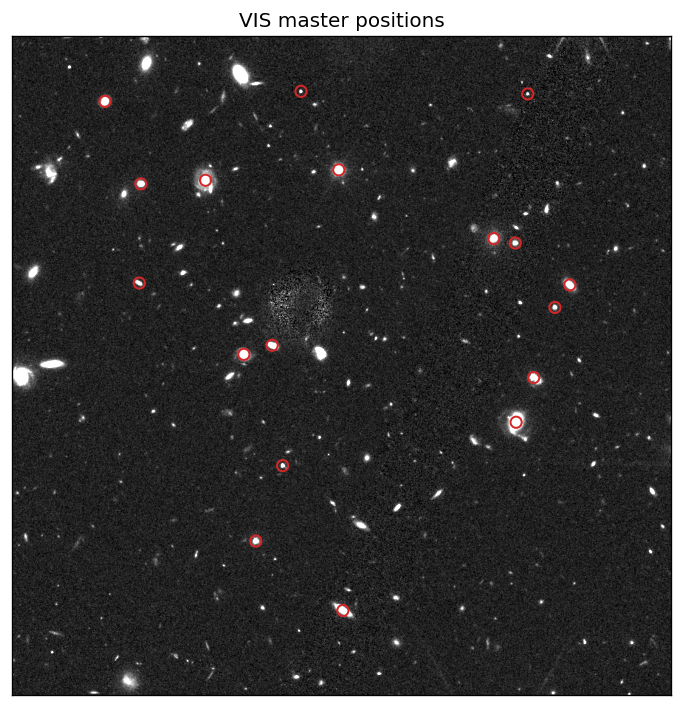

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
vis = euclid['img'][0]
vmin, vmax = np.nanpercentile(vis, [2, 99.5])
ax.imshow(vis, cmap='gray', vmin=vmin, vmax=vmax)
if len(vis_pos):
    ax.scatter(vis_pos[:, 0], vis_pos[:, 1], s=45, facecolors='none', edgecolors='tab:red', lw=1.2)
ax.set_title('VIS master positions')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


## PSF-only compact-source baseline

This is not expected to be perfect for extended galaxies. It tells us how much residual structure remains if every source is treated as a PSF.

In [7]:
euclid_bands = ['euclid_VIS', 'euclid_Y', 'euclid_J', 'euclid_H']

euclid_pipe = PSFFieldPhotometryPipeline.from_checkpoint(
    PSF_CKPT,
    band_names=euclid_bands,
    stamp_size=MORPH_SIZE,
    sub_grid=SUB_GRID,
    bg_inner_radius=10.0,
    bg_outer_radius=14.0,
    device=DEVICE,
)

euclid_tile = as_tensor(euclid['img'])
euclid_rms = as_tensor(euclid['rms'])

psf_out = euclid_pipe.run(
    euclid_tile,
    euclid_rms,
    vis_pos,
    return_psfs=True,
    return_stamps=True,
)
psf_chi2 = psf_out['chi2_dof'].detach().cpu().numpy()
print('PSF-only median chi2/dof:')
for b, name in enumerate(euclid_bands):
    print(f'  {name:10s}: {np.nanmedian(psf_chi2[:, b]):7.3f}')


PSF-only median chi2/dof:
  euclid_VIS:  13.654
  euclid_Y  :   1.147
  euclid_J  :   2.960
  euclid_H  :   3.353


## Fit scarlet-like residual scenes

The morphology is initialized from VIS, then optimized jointly with non-negative per-band fluxes. Neighboring sources are grouped so blends are fitted in one local scene rather than source-by-source.

In [8]:
morph_pack = make_positive_morphology_templates(
    euclid_tile[0],
    vis_pos.to(DEVICE),
    stamp_size=MORPH_SIZE,
    bg_inner_radius=11.0,
    bg_outer_radius=15.0,
    smooth_sigma=0.6,
)
init_morph = morph_pack['templates']
print('Initial morphology templates:', tuple(init_morph.shape))

groups = build_neighbor_groups(vis_pos, radius_px=GROUP_RADIUS)
print(f'Blend groups: {len(groups)} groups for {len(vis_pos)} sources')
print('Group sizes:', [len(g) for g in groups])


Initial morphology templates: (18, 31, 31)
Blend groups: 18 groups for 18 sources
Group sizes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [9]:
psfs = euclid_pipe.render_psfs(vis_pos, tile_hw=euclid_tile.shape[-2:])
print('Rendered PSFs:', tuple(psfs.shape))

scarlet_out = fit_scarlet_like_tile(
    euclid_tile,
    euclid_rms,
    vis_pos.to(DEVICE),
    init_morph,
    psfs=psfs,
    groups=groups,
    min_scene_size=SCENE_MIN,
    max_scene_size=SCENE_MAX,
    n_steps=N_STEPS,
    lr=LR,
    tv_weight=1e-4,
    center_weight=1e-3,
    morph_anchor_weight=2e-2,
    background_anchor_weight=1e-2,
    train_morphology=True,
    train_background=False,
)

scarlet_chi2 = scarlet_out['chi2_dof'].detach().cpu().numpy()
print('Scarlet-like median chi2/dof:')
for b, name in enumerate(euclid_bands):
    print(f'  {name:10s}: {np.nanmedian(scarlet_chi2[:, b]):7.3f}')


Rendered PSFs: (18, 4, 31, 31)


Scarlet-like median chi2/dof:
  euclid_VIS:   0.589
  euclid_Y  :   0.117
  euclid_J  :   0.188
  euclid_H  :   0.277


Saved io/scarlet_like_chi2_compare.png


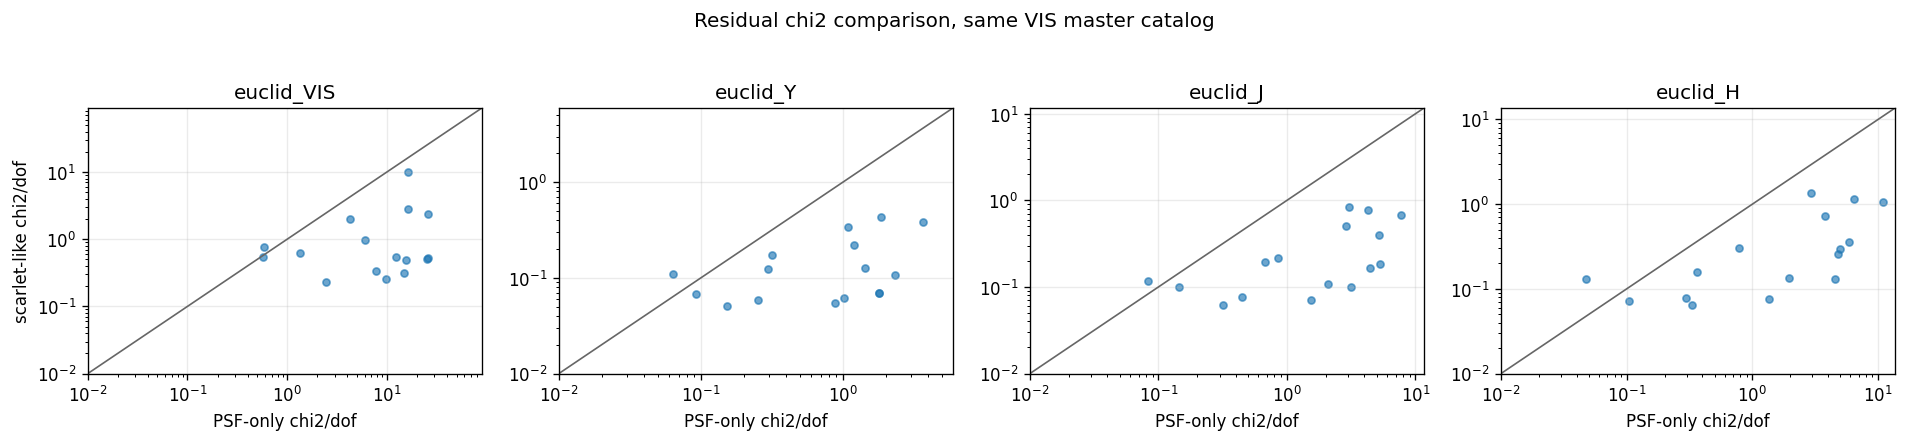

In [10]:
def savefig(path):
    plt.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved {Path(path).relative_to(ROOT)}')


def plot_chi2_compare(psf_out, scarlet_out, save_path=None):
    psf_chi = psf_out['chi2_dof'].detach().cpu().numpy()
    sc_chi = scarlet_out['chi2_dof'].detach().cpu().numpy()
    fig, axes = plt.subplots(1, len(euclid_bands), figsize=(4 * len(euclid_bands), 3.5))
    for b, ax in enumerate(axes):
        x = np.clip(psf_chi[:, b], 1e-3, None)
        y = np.clip(sc_chi[:, b], 1e-3, None)
        ax.scatter(x, y, s=18, alpha=0.65)
        lim = np.nanpercentile(np.concatenate([x, y]), 95)
        lim = max(lim, 2.0)
        ax.plot([1e-3, lim], [1e-3, lim], color='0.4', lw=1)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(1e-2, lim); ax.set_ylim(1e-2, lim)
        ax.set_title(euclid_bands[b])
        ax.set_xlabel('PSF-only chi2/dof')
        if b == 0:
            ax.set_ylabel('scarlet-like chi2/dof')
        ax.grid(alpha=0.25)
    fig.suptitle('Residual chi2 comparison, same VIS master catalog', y=1.04)
    plt.tight_layout()
    if save_path:
        savefig(save_path)
    plt.show()


plot_chi2_compare(psf_out, scarlet_out, OUT_DIR / 'scarlet_like_chi2_compare.png')


Saved io/scarlet_like_loss_curves.png


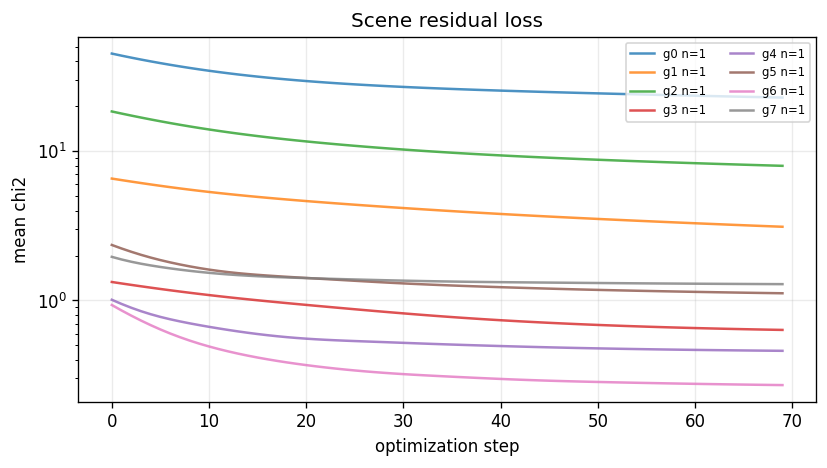

In [11]:
def plot_loss_curves(scene_out, n_show=8, save_path=None):
    scenes = scene_out['scene_results']
    fig, ax = plt.subplots(figsize=(7, 4))
    for scene in scenes[:n_show]:
        hist = scene['result'].loss_history.detach().cpu().numpy()
        ax.plot(hist[:, 1], alpha=0.8, label=f'g{scene["group_id"]} n={len(scene["indices"])}')
    ax.set_title('Scene residual loss')
    ax.set_xlabel('optimization step')
    ax.set_ylabel('mean chi2')
    ax.set_yscale('log')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    if save_path:
        savefig(save_path)
    plt.show()


plot_loss_curves(scarlet_out, save_path=OUT_DIR / 'scarlet_like_loss_curves.png')


## Good residual scenes first

The first gallery deliberately starts with low residual scenes. Use this to calibrate what success looks like before looking at failures.

Saved io/scarlet_like_euclid_vis_good_gallery.png


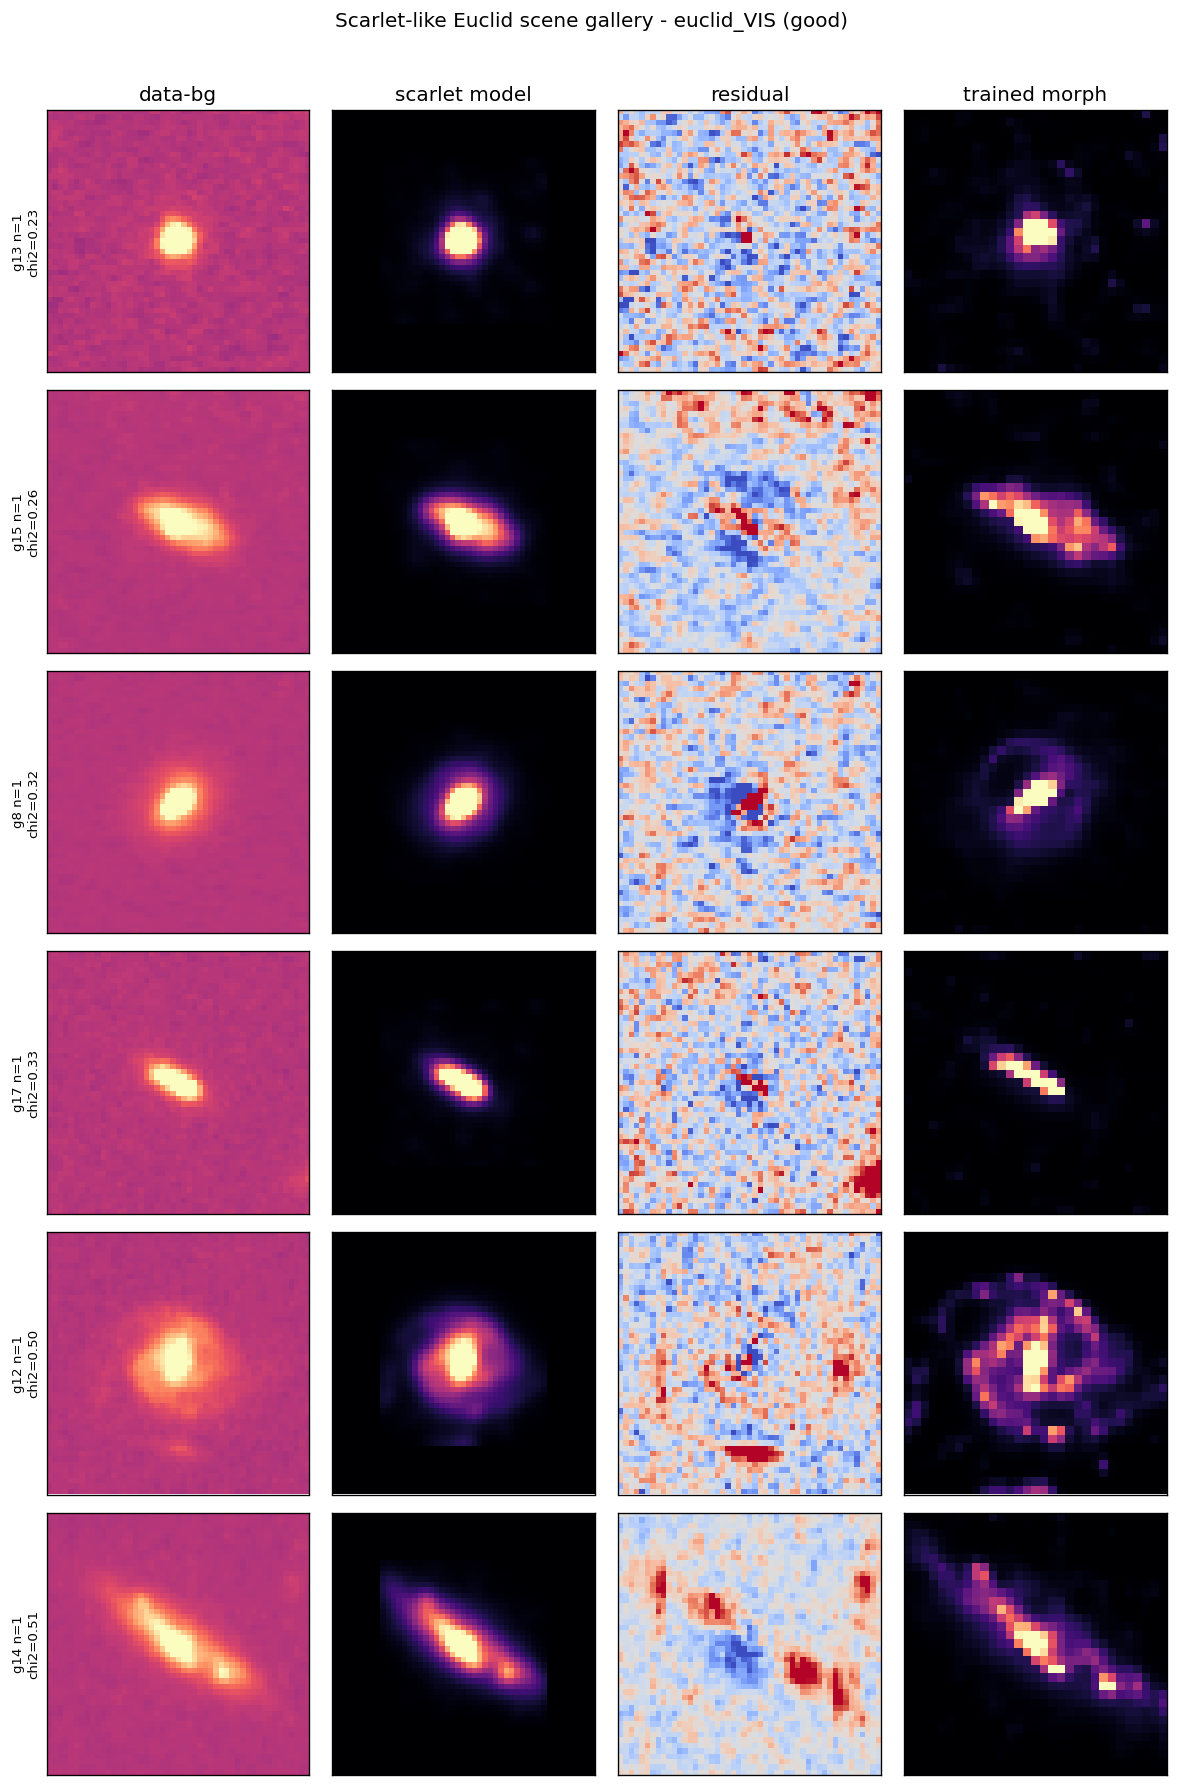

In [12]:
def scene_band_chi2(scene, band=0):
    return float(scene['result'].chi2_dof[band].detach().cpu())


def plot_scene_gallery(scene_out, band=0, mode='good', n_show=6, save_path=None):
    scenes = list(scene_out['scene_results'])
    if mode == 'good':
        scenes = sorted(scenes, key=lambda s: scene_band_chi2(s, band))
    elif mode == 'worst':
        scenes = sorted(scenes, key=lambda s: scene_band_chi2(s, band), reverse=True)
    scenes = scenes[:n_show]
    if not scenes:
        print('No scenes to plot')
        return

    fig, axes = plt.subplots(len(scenes), 4, figsize=(10, 2.45 * len(scenes)))
    if len(scenes) == 1:
        axes = axes[None, :]

    for row, scene in enumerate(scenes):
        result = scene['result']
        data = scene['data'][band].detach().cpu().numpy()
        bg = float(result.background[band].detach().cpu())
        model = result.model[band].detach().cpu().numpy()
        resid = result.resid[band].detach().cpu().numpy()
        model_sub = model - bg
        data_sub = data - bg
        morph = result.morphology[0].detach().cpu().numpy()
        if len(scene['indices']) > 1:
            morph = result.morphology.detach().cpu().sum(dim=0).numpy()
            morph = morph / max(morph.sum(), 1e-20)

        vmax = np.nanpercentile(np.abs(data_sub), 99)
        rv = np.nanpercentile(np.abs(resid), 98)
        panels = [
            (data_sub, 'data-bg', 'magma', -vmax, vmax),
            (model_sub, 'scarlet model', 'magma', 0, np.nanpercentile(model_sub, 99)),
            (resid, 'residual', 'coolwarm', -rv, rv),
            (morph, 'trained morph', 'magma', 0, np.nanpercentile(morph, 99)),
        ]
        for col, (arr, title, cmap, vmin, vmax_i) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax_i)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(title)
        axes[row, 0].set_ylabel(
            f'g{scene["group_id"]} n={len(scene["indices"])}\nchi2={scene_band_chi2(scene, band):.2f}',
            fontsize=8,
        )
    fig.suptitle(f'Scarlet-like Euclid scene gallery - {euclid_bands[band]} ({mode})', y=1.01)
    plt.tight_layout()
    if save_path:
        savefig(save_path)
    plt.show()


plot_scene_gallery(
    scarlet_out,
    band=euclid_bands.index('euclid_VIS'),
    mode='good',
    n_show=6,
    save_path=OUT_DIR / 'scarlet_like_euclid_vis_good_gallery.png',
)


## Then inspect failures

These are the scenes to compare against Tractor or a later learned morphology head. Common causes should be blends, bad initial morphology, edge/background problems, or sources whose color morphology really changes between VIS and NISP.

Saved io/scarlet_like_euclid_vis_worst_gallery.png


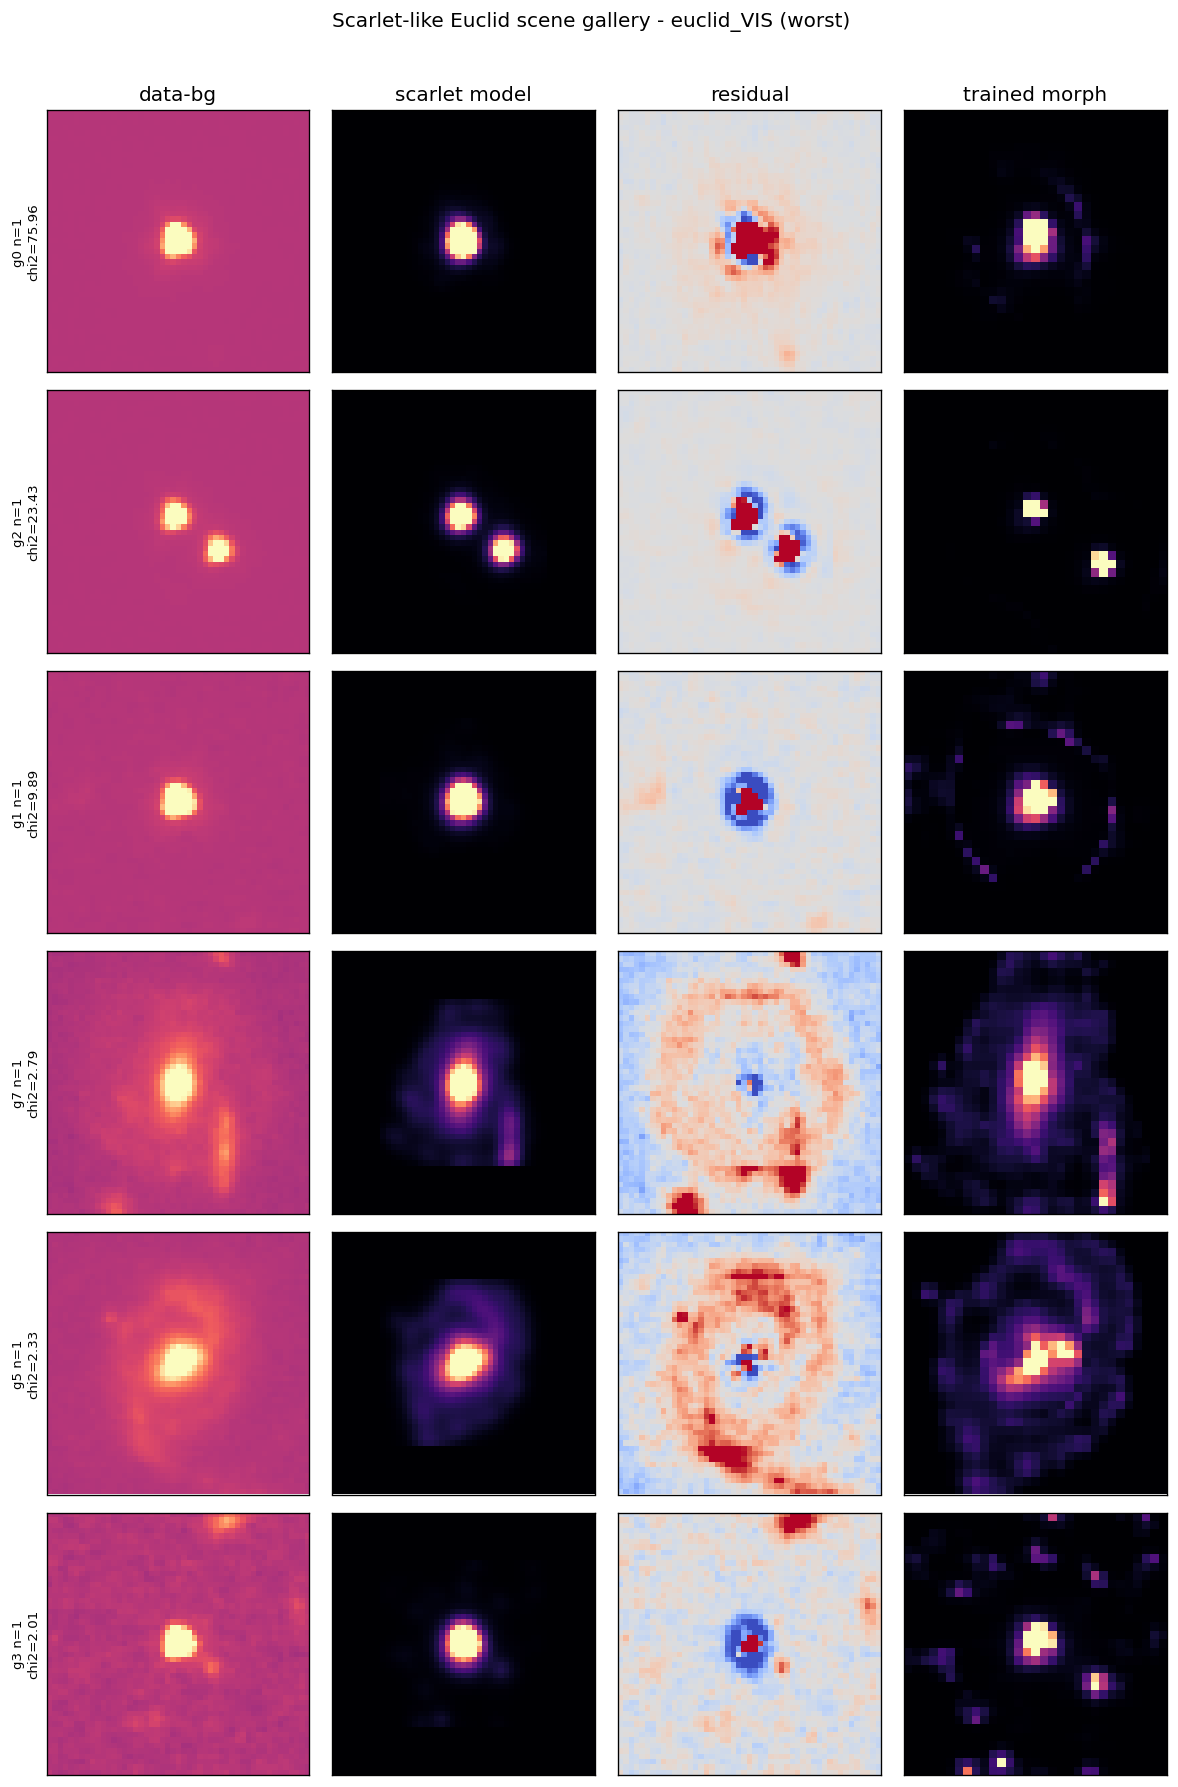

In [13]:
plot_scene_gallery(
    scarlet_out,
    band=euclid_bands.index('euclid_VIS'),
    mode='worst',
    n_show=6,
    save_path=OUT_DIR / 'scarlet_like_euclid_vis_worst_gallery.png',
)


In [14]:
flux = scarlet_out['flux'].detach().cpu().numpy()
print('Flux finite:', np.isfinite(flux).all())
for b, name in enumerate(euclid_bands):
    print(f'{name:10s} flux median={np.nanmedian(flux[:, b]):10.3g} p90={np.nanpercentile(flux[:, b], 90):10.3g}')

print('\nSaved figures:')
for path in [
    OUT_DIR / 'scarlet_like_chi2_compare.png',
    OUT_DIR / 'scarlet_like_loss_curves.png',
    OUT_DIR / 'scarlet_like_euclid_vis_good_gallery.png',
    OUT_DIR / 'scarlet_like_euclid_vis_worst_gallery.png',
]:
    print(' ', path.relative_to(ROOT), 'OK' if path.exists() else 'MISSING')


Flux finite: True
euclid_VIS flux median=      14.2 p90=      34.1
euclid_Y   flux median=  3.76e+03 p90=  1.79e+04
euclid_J   flux median=  6.62e+03 p90=  2.69e+04
euclid_H   flux median=  7.96e+03 p90=  2.79e+04

Saved figures:
  io/scarlet_like_chi2_compare.png OK
  io/scarlet_like_loss_curves.png OK
  io/scarlet_like_euclid_vis_good_gallery.png OK
  io/scarlet_like_euclid_vis_worst_gallery.png OK
